# 🧠 Profiling Plus Modeling Loop — Persona Identification Pipeline
### Full Architecture: Feature Engineering → Clustering → Evaluation → Explainability → LLM Persona ID (Ollama/llama3)

**Architecture Flow:**
```
Start → Data Input → Feature Engineering → Select/Configure Clustering Runs
     → [K-Means | DBSCAN | GMM] → Cluster Evaluation
     → Evaluation Pass?
          No  → Reconfigure & Retry (up to N iterations)
          Yes → Explainability (SHAP-style + PCA + Inertia)
              → Feature List Driving Convergence
              → Persona Identification Layer  ← LOCAL LLM (Ollama llama3)
              → Ground in Business Objective
              → [Cluster A | Cluster B | Cluster C] → End
```


## Cell 1 — Requirements
Install required packages (run once).

In [1]:
# ── Requirements ─────────────────────────────────────────────────────────────
# Run this cell once to install dependencies.
# Ollama must be separately installed: https://ollama.com/download
# Then pull the model:  ollama pull llama3

import subprocess, sys

PACKAGES = [
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "openpyxl",      # Excel support
    "pyarrow",       # Parquet support
    "requests",      # Ollama HTTP API
]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All packages installed.")
print("⚠️  Make sure Ollama is running:  ollama serve")
print("⚠️  Make sure llama3 is pulled:   ollama pull llama3")


✅ All packages installed.
⚠️  Make sure Ollama is running:  ollama serve
⚠️  Make sure llama3 is pulled:   ollama pull llama3


## Cell 2 — Imports & Global Config

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
from __future__ import annotations

import json
import logging
import math
import os
import re
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Literal, Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("persona_pipeline")

# ── Global palette ────────────────────────────────────────────────────────────
PALETTE  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

print("✅ Imports complete.")


✅ Imports complete.


## Cell 3 — Pipeline Configuration
Edit this cell to configure your run.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  PIPELINE CONFIGURATION  ← Edit this block
# ═══════════════════════════════════════════════════════════════════════════

# ── Data source ───────────────────────────────────────────────────────────────
DATA_SOURCE: Literal["csv", "parquet", "excel", "synthetic"] = "synthetic"
DATA_PATH: str = ""           # e.g. "data/customers.csv" — leave "" for synthetic

# ── Target / ID columns to exclude from clustering ───────────────────────────
EXCLUDE_COLS: list[str] = ["customer_id", "cluster_truth"]

# ── Clustering ────────────────────────────────────────────────────────────────
K_RANGE          = (2, 6)         # min/max k to search over for K-Means & GMM
DBSCAN_EPS       = 0.5
DBSCAN_MIN_SAMP  = 10
MAX_ITERATIONS   = 5              # max modeling loop retries if eval fails

# ── Evaluation thresholds ─────────────────────────────────────────────────────
SILHOUETTE_THRESHOLD  = 0.25     # below this → loop again
DB_THRESHOLD          = 2.0      # Davies-Bouldin: lower is better

# ── Explainability ────────────────────────────────────────────────────────────
N_TOP_FEATURES   = 8              # how many driving features to surface

# ── Ollama / Local LLM ───────────────────────────────────────────────────────
OLLAMA_HOST      = "http://localhost:11434"
OLLAMA_MODEL     = "llama3"
OLLAMA_TIMEOUT   = 120            # seconds

# ── Business objective (used by LLM for grounding) ───────────────────────────
BUSINESS_OBJECTIVE = (
    "Identify distinct customer segments to personalise marketing campaigns, "
    "improve retention for high-value customers, and convert mid-tier customers "
    "to premium products."
)

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("persona_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Configuration loaded.")
print(f"   Data source  : {DATA_SOURCE}")
print(f"   Ollama model : {OLLAMA_MODEL} @ {OLLAMA_HOST}")
print(f"   Max retries  : {MAX_ITERATIONS}")
print(f"   Output dir   : {OUTPUT_DIR.resolve()}")


✅ Configuration loaded.
   Data source  : synthetic
   Ollama model : llama3 @ http://localhost:11434
   Max retries  : 5
   Output dir   : C:\Users\UmairAhmed\OneDrive - Blend 360\Documents\Segmentation_Plus\persona_output


## Cell 4 — Data Input Layer
Supports CSV, Parquet, Excel, and synthetic data generation.

In [4]:
# ── Data Input Layer ─────────────────────────────────────────────────────────

@dataclass
class ColumnMeta:
    name: str
    dtype: Literal["numeric", "categorical", "datetime", "text", "boolean"]
    null_rate: float
    n_unique: int

@dataclass
class DataSchema:
    n_rows: int
    n_cols: int
    columns: list[ColumnMeta] = field(default_factory=list)

    @property
    def numeric_cols(self) -> list[str]:
        return [c.name for c in self.columns if c.dtype == "numeric"]

    @property
    def categorical_cols(self) -> list[str]:
        return [c.name for c in self.columns if c.dtype == "categorical"]


def infer_schema(df: pd.DataFrame) -> DataSchema:
    cols = []
    for col in df.columns:
        s = df[col]
        nu = s.nunique()
        if pd.api.types.is_bool_dtype(s):
            dtype = "boolean"
        elif pd.api.types.is_datetime64_any_dtype(s):
            dtype = "datetime"
        elif pd.api.types.is_numeric_dtype(s):
            dtype = "numeric"
        elif nu / max(len(s), 1) < 0.05 or nu <= 20:
            dtype = "categorical"
        else:
            dtype = "text"
        cols.append(ColumnMeta(col, dtype, s.isna().mean(), nu))
    return DataSchema(len(df), len(df.columns), cols)


def _generate_synthetic() -> pd.DataFrame:
    """3-cluster synthetic customer dataset with realistic feature distributions."""
    rng = np.random.default_rng(42)
    N = 2000

    def make_cluster(n, age_mu, spend_mu, freq_mu, aov_mu, days_mu, nps_mu,
                     mobile_p, premium_p, seed_offset=0):
        return pd.DataFrame({
            "age":                    rng.normal(age_mu,   6,  n).clip(18, 75).astype(int),
            "annual_spend":           rng.normal(spend_mu, spend_mu*0.15, n).clip(100, 20000).round(2),
            "purchase_frequency":     rng.normal(freq_mu,  freq_mu*0.2,  n).clip(1,  52).astype(int),
            "avg_order_value":        rng.normal(aov_mu,   aov_mu*0.18,  n).clip(10, 1000).round(2),
            "days_since_last_purchase": rng.normal(days_mu, days_mu*0.3, n).clip(1, 365).astype(int),
            "support_tickets_12m":    rng.poisson(0.5 + seed_offset*0.8, n),
            "nps_score":              rng.normal(nps_mu, 0.8, n).clip(1, 10).round(1),
            "lifetime_months":        rng.normal(24 + seed_offset*12, 8, n).clip(1, 120).astype(int),
            "channel":                rng.choice(["mobile","web","in-store"], n, p=[mobile_p, 1-mobile_p-0.05, 0.05]),
            "region":                 rng.choice(["North","South","East","West"], n),
            "product_category":       rng.choice(["premium","standard","budget"], n,
                                                  p=[premium_p, 1-premium_p-0.1, 0.1]),
        })

    df_a = make_cluster(N//3, age_mu=36, spend_mu=9000, freq_mu=26, aov_mu=340,
                        days_mu=7,  nps_mu=9.0, mobile_p=0.65, premium_p=0.80, seed_offset=0)
    df_b = make_cluster(N//3, age_mu=28, spend_mu=1600, freq_mu=5,  aov_mu=80,
                        days_mu=70, nps_mu=6.0, mobile_p=0.30, premium_p=0.08, seed_offset=2)
    df_c = make_cluster(N-2*(N//3), age_mu=46, spend_mu=4200, freq_mu=13, aov_mu=190,
                        days_mu=28, nps_mu=7.5, mobile_p=0.50, premium_p=0.42, seed_offset=1)

    df_a["cluster_truth"] = "A"
    df_b["cluster_truth"] = "B"
    df_c["cluster_truth"] = "C"

    df = pd.concat([df_a, df_b, df_c], ignore_index=True)
    return df.sample(frac=1, random_state=42).reset_index(drop=True)


def load_data(source: str, path: str) -> pd.DataFrame:
    loaders = {
        "csv":       lambda p: pd.read_csv(p),
        "parquet":   lambda p: pd.read_parquet(p),
        "excel":     lambda p: pd.read_excel(p),
        "synthetic": lambda p: _generate_synthetic(),
    }
    if source not in loaders:
        raise ValueError(f"Unknown source {source!r}. Choose from {list(loaders)}")
    df = loaders[source](path or None)
    log.info("Loaded data: %d rows × %d cols", *df.shape)
    return df


# ── Run Data Input ────────────────────────────────────────────────────────────
raw_df = load_data(DATA_SOURCE, DATA_PATH)
schema = infer_schema(raw_df)

print(f"\n📊 Dataset Overview")
print(f"   Rows            : {schema.n_rows:,}")
print(f"   Columns         : {schema.n_cols}")
print(f"   Numeric cols    : {schema.numeric_cols}")
print(f"   Categorical cols: {schema.categorical_cols}")
print()
raw_df.head()


13:07:49 | INFO     | Loaded data: 2000 rows × 12 cols



📊 Dataset Overview
   Rows            : 2,000
   Columns         : 12
   Numeric cols    : ['age', 'annual_spend', 'purchase_frequency', 'avg_order_value', 'days_since_last_purchase', 'support_tickets_12m', 'nps_score', 'lifetime_months']
   Categorical cols: ['channel', 'region', 'product_category', 'cluster_truth']



,age,annual_spend,purchase_frequency,avg_order_value,days_since_last_purchase,support_tickets_12m,nps_score,lifetime_months,channel,region,product_category,cluster_truth
0,41,3762.86,9,240.43,12,2,6.3,31,mobile,North,premium,C
1,40,9836.60,29,378.04,9,0,9.0,29,mobile,South,premium,A
2,48,4082.73,14,246.09,25,0,9.1,39,mobile,North,standard,C
3,27,1541.50,5,91.20,57,1,6.7,49,web,South,standard,B
4,27,1775.54,6,87.41,48,2,6.1,41,web,South,standard,B


## Cell 5 — Feature Engineering
Imputation → Encoding → Outlier clipping → Scaling → PCA (optional)

In [5]:
# ── Feature Engineering ──────────────────────────────────────────────────────

class FeatureEngineer:
    """
    Stateless-first feature engineering. Call .fit_transform() once;
    subsequent calls to .transform() reuse fitted state for consistency.
    """

    def __init__(self, exclude_cols: list[str]):
        self.exclude_cols  = exclude_cols
        self._imputer: SimpleImputer | None   = None
        self._scaler:  StandardScaler | None  = None
        self._encoders: dict[str, LabelEncoder] = {}
        self._feature_cols: list[str]         = []
        self._fitted = False

    def fit_transform(self, df: pd.DataFrame, schema: DataSchema) -> pd.DataFrame:
        df = df.copy()
        # Drop excluded
        df.drop(columns=[c for c in self.exclude_cols if c in df.columns], inplace=True)

        num_cols = [c for c in schema.numeric_cols if c in df.columns]
        cat_cols = [c for c in schema.categorical_cols if c in df.columns]

        # Encode categoricals
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self._encoders[col] = le

        self._feature_cols = num_cols + cat_cols
        X = df[self._feature_cols].copy()

        # Impute
        self._imputer = SimpleImputer(strategy="median")
        X_arr = self._imputer.fit_transform(X)
        X = pd.DataFrame(X_arr, columns=self._feature_cols)

        # Clip outliers (1st–99th percentile)
        for col in num_cols:
            lo, hi = X[col].quantile([0.01, 0.99])
            X[col] = X[col].clip(lo, hi)

        # Scale
        self._scaler = StandardScaler()
        X_scaled = self._scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=self._feature_cols)

        self._fitted = True
        log.info("Feature engineering complete: %s features", len(self._feature_cols))
        return X

    @property
    def feature_names(self) -> list[str]:
        return list(self._feature_cols)


fe = FeatureEngineer(exclude_cols=EXCLUDE_COLS)
features_df = fe.fit_transform(raw_df, schema)
X = features_df.values

print(f"✅ Feature matrix shape : {X.shape}")
print(f"   Features             : {fe.feature_names}")
features_df.describe().round(3)


13:08:03 | INFO     | Feature engineering complete: 11 features


✅ Feature matrix shape : (2000, 11)
   Features             : ['age', 'annual_spend', 'purchase_frequency', 'avg_order_value', 'days_since_last_purchase', 'support_tickets_12m', 'nps_score', 'lifetime_months', 'channel', 'region', 'product_category']


,age,annual_spend,purchase_frequency,avg_order_value,days_since_last_purchase,support_tickets_12m,nps_score,lifetime_months,channel,region,product_category
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.911,-1.185,-1.222,-1.322,-1.088,-1.001,-2.026,-2.121,-2.494,-1.373,-2.062
25%,-0.741,-1.005,-1.000,-1.008,-0.913,-1.001,-0.824,-0.768,-0.756,-0.469,-0.534
50%,0.003,-0.225,-0.115,-0.093,-0.250,-0.223,0.024,-0.052,-0.756,0.434,-0.534
75%,0.748,0.991,0.798,0.829,0.727,0.556,0.802,0.744,0.983,0.434,0.994
max,2.236,2.058,2.319,2.251,2.543,2.892,1.791,2.177,0.983,1.338,0.994


## Cell 6 — Clustering Algorithms
K-Means (distance-based), DBSCAN (density-based), GMM/EM (probabilistic)

In [6]:
# ── Clustering Configurator & Runners ────────────────────────────────────────

@dataclass
class ClusteringConfig:
    k: int = 3
    kmeans_init: str = "k-means++"
    kmeans_n_init: int = 10
    kmeans_max_iter: int = 300
    dbscan_eps: float = DBSCAN_EPS
    dbscan_min_samples: int = DBSCAN_MIN_SAMP
    gmm_covariance_type: str = "full"
    gmm_n_init: int = 5
    random_state: int = 42


@dataclass
class ClusterRunResult:
    algorithm: str
    labels: np.ndarray
    n_clusters: int
    model: object


class ClusteringConfigurator:
    """
    Selects the optimal k for K-Means / GMM using elbow + silhouette.
    Reconfigures on failed evaluation by nudging k and eps.
    """

    def __init__(self, k_range: tuple[int, int]):
        self.k_range = k_range

    def configure(self, X: np.ndarray) -> ClusteringConfig:
        best_k, best_score = self.k_range[0], -1.0
        scores = {}
        for k in range(self.k_range[0], self.k_range[1] + 1):
            km = KMeans(n_clusters=k, init="k-means++", n_init=5, random_state=42)
            lbl = km.fit_predict(X)
            if len(set(lbl)) < 2:
                continue
            s = silhouette_score(X, lbl, sample_size=min(1000, len(X)))
            scores[k] = round(s, 4)
            if s > best_score:
                best_score, best_k = s, k
        log.info("  K search → scores: %s | selected k=%d (sil=%.4f)", scores, best_k, best_score)
        return ClusteringConfig(k=best_k)

    def reconfigure(self, X: np.ndarray, cfg: ClusteringConfig, iteration: int) -> ClusteringConfig:
        """Nudge parameters when evaluation fails."""
        new_k   = min(cfg.k + 1, self.k_range[1])
        new_eps = round(cfg.dbscan_eps * 1.2, 3)
        log.info("  Reconfiguring: k %d→%d, eps %.3f→%.3f", cfg.k, new_k, cfg.dbscan_eps, new_eps)
        return ClusteringConfig(k=new_k, dbscan_eps=new_eps)


def run_kmeans(X: np.ndarray, cfg: ClusteringConfig) -> ClusterRunResult:
    model = KMeans(
        n_clusters=cfg.k,
        init=cfg.kmeans_init,
        n_init=cfg.kmeans_n_init,
        max_iter=cfg.kmeans_max_iter,
        random_state=cfg.random_state,
    )
    labels = model.fit_predict(X)
    return ClusterRunResult("kmeans", labels, len(set(labels)), model)


def run_dbscan(X: np.ndarray, cfg: ClusteringConfig) -> ClusterRunResult:
    model = DBSCAN(eps=cfg.dbscan_eps, min_samples=cfg.dbscan_min_samples)
    labels = model.fit_predict(X)
    n = len(set(labels)) - (1 if -1 in labels else 0)
    return ClusterRunResult("dbscan", labels, max(n, 1), model)


def run_gmm(X: np.ndarray, cfg: ClusteringConfig) -> ClusterRunResult:
    model = GaussianMixture(
        n_components=cfg.k,
        covariance_type=cfg.gmm_covariance_type,
        n_init=cfg.gmm_n_init,
        random_state=cfg.random_state,
    )
    labels = model.fit_predict(X)
    return ClusterRunResult("gmm", labels, len(set(labels)), model)


print("✅ Clustering algorithms defined (K-Means, DBSCAN, GMM).")


✅ Clustering algorithms defined (K-Means, DBSCAN, GMM).


## Cell 7 — Cluster Evaluator
Silhouette, Davies-Bouldin, Calinski-Harabasz scoring with pass/fail gate.

In [7]:
# ── Cluster Evaluator ────────────────────────────────────────────────────────

@dataclass
class EvaluationResult:
    algorithm: str
    labels: np.ndarray
    n_clusters: int
    silhouette: float
    davies_bouldin: float
    calinski_harabasz: float
    passes: bool
    all_scores: dict = field(default_factory=dict)


class ClusterEvaluator:
    """
    Evaluates all three algorithm outputs and selects the best one.
    Pass criteria: silhouette ≥ threshold AND davies_bouldin ≤ threshold.
    """

    def __init__(self, sil_threshold: float, db_threshold: float):
        self.sil_threshold = sil_threshold
        self.db_threshold  = db_threshold

    def _score_one(self, X: np.ndarray, result: ClusterRunResult) -> dict:
        lbl = result.labels
        valid = lbl[lbl != -1]           # exclude DBSCAN noise
        X_v   = X[lbl != -1]

        if len(set(valid)) < 2 or len(X_v) < 10:
            return {"silhouette": -1.0, "davies_bouldin": 99.0, "calinski_harabasz": 0.0}

        sample = min(2000, len(X_v))
        sil  = silhouette_score(X_v, valid, sample_size=sample)
        db   = davies_bouldin_score(X_v, valid)
        ch   = calinski_harabasz_score(X_v, valid)
        return {"silhouette": round(sil, 4), "davies_bouldin": round(db, 4),
                "calinski_harabasz": round(ch, 2)}

    def evaluate(
        self,
        X: np.ndarray,
        results: dict[str, ClusterRunResult],
    ) -> EvaluationResult:
        scored = {}
        for name, res in results.items():
            s = self._score_one(X, res)
            s["n_clusters"] = res.n_clusters
            scored[name] = s
            log.info(
                "  [%s] k=%d | sil=%.4f | DB=%.4f | CH=%.1f",
                name, res.n_clusters, s["silhouette"], s["davies_bouldin"], s["calinski_harabasz"]
            )

        # Pick best by silhouette
        best_name = max(scored, key=lambda n: scored[n]["silhouette"])
        best_s    = scored[best_name]
        best_res  = results[best_name]
        passes    = (best_s["silhouette"] >= self.sil_threshold and
                     best_s["davies_bouldin"] <= self.db_threshold)

        return EvaluationResult(
            algorithm          = best_name,
            labels             = best_res.labels,
            n_clusters         = best_res.n_clusters,
            silhouette         = best_s["silhouette"],
            davies_bouldin     = best_s["davies_bouldin"],
            calinski_harabasz  = best_s["calinski_harabasz"],
            passes             = passes,
            all_scores         = scored,
        )


evaluator    = ClusterEvaluator(SILHOUETTE_THRESHOLD, DB_THRESHOLD)
configurator = ClusteringConfigurator(K_RANGE)
print("✅ Evaluator and configurator ready.")


✅ Evaluator and configurator ready.


## Cell 8 — 🔁 Modeling Loop
Runs all three algorithms per iteration. Retries with reconfigured parameters if evaluation fails.

In [8]:
# ── Modeling Loop ────────────────────────────────────────────────────────────

def modeling_loop(
    X: np.ndarray,
    configurator: ClusteringConfigurator,
    evaluator: ClusterEvaluator,
    max_iterations: int,
) -> tuple[EvaluationResult, ClusteringConfig]:
    """
    Implements the core retry loop from the architecture diagram.
    Returns the best EvaluationResult and the config that produced it.
    """
    config = configurator.configure(X)
    best_eval: EvaluationResult | None = None

    for iteration in range(1, max_iterations + 1):
        print(f"\n{'─'*60}")
        print(f"  Modeling Loop — Iteration {iteration}/{max_iterations} | k={config.k}")
        print(f"{'─'*60}")

        # Run all three clustering algorithms
        results: dict[str, ClusterRunResult] = {
            "kmeans": run_kmeans(X, config),
            "dbscan": run_dbscan(X, config),
            "gmm":    run_gmm(X, config),
        }

        print(f"  K-Means clusters : {results['kmeans'].n_clusters}")
        print(f"  DBSCAN  clusters : {results['dbscan'].n_clusters}  (excl. noise)")
        print(f"  GMM     clusters : {results['gmm'].n_clusters}")

        # Evaluate
        eval_result = evaluator.evaluate(X, results)
        print(f"\n  Best algorithm   : {eval_result.algorithm.upper()}")
        print(f"  Silhouette score : {eval_result.silhouette:.4f}  (threshold ≥ {SILHOUETTE_THRESHOLD})")
        print(f"  Davies-Bouldin   : {eval_result.davies_bouldin:.4f}  (threshold ≤ {DB_THRESHOLD})")
        print(f"  Calinski-Harabasz: {eval_result.calinski_harabasz:.1f}")
        print(f"  Evaluation PASS  : {'✅ YES' if eval_result.passes else '❌ NO'}")

        if eval_result.passes:
            best_eval = eval_result
            print(f"\n  🎯 Accepted on iteration {iteration}.")
            break
        else:
            print(f"\n  ↩️  Poor separation. Reconfiguring for next iteration...")
            config = configurator.reconfigure(X, config, iteration)

    if best_eval is None:
        print("\n⚠️  Max iterations reached without passing. Using best found result.")
        best_eval = eval_result   # use last iteration's result

    return best_eval, config


# ── Execute the loop ──────────────────────────────────────────────────────────
t0 = time.time()
best_eval, final_config = modeling_loop(X, configurator, evaluator, MAX_ITERATIONS)
elapsed = time.time() - t0

print(f"\n{'═'*60}")
print(f"  MODELING LOOP COMPLETE in {elapsed:.1f}s")
print(f"  Algorithm : {best_eval.algorithm.upper()}")
print(f"  Clusters  : {best_eval.n_clusters}")
print(f"  Silhouette: {best_eval.silhouette:.4f}")
print(f"{'═'*60}")

# Attach cluster labels back to raw data
labeled_df = raw_df.copy()
labeled_df["cluster_id"] = best_eval.labels


  File "c:\Users\UmairAhmed\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\UmairAhmed\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\UmairAhmed\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\UmairAhmed\anaco


────────────────────────────────────────────────────────────
  Modeling Loop — Iteration 1/5 | k=2
────────────────────────────────────────────────────────────


13:09:00 | INFO     |   [kmeans] k=2 | sil=0.3386 | DB=1.1594 | CH=1240.2
13:09:00 | INFO     |   [dbscan] k=1 | sil=-1.0000 | DB=99.0000 | CH=0.0
13:09:01 | INFO     |   [gmm] k=2 | sil=0.3412 | DB=1.1442 | CH=1232.0


  K-Means clusters : 2
  DBSCAN  clusters : 1  (excl. noise)
  GMM     clusters : 2

  Best algorithm   : GMM
  Silhouette score : 0.3412  (threshold ≥ 0.25)
  Davies-Bouldin   : 1.1442  (threshold ≤ 2.0)
  Calinski-Harabasz: 1232.0
  Evaluation PASS  : ✅ YES

  🎯 Accepted on iteration 1.

════════════════════════════════════════════════════════════
  MODELING LOOP COMPLETE in 1.0s
  Algorithm : GMM
  Clusters  : 2
  Silhouette: 0.3412
════════════════════════════════════════════════════════════


## Cell 9 — Cluster Visualisation (PCA 2D Projection)

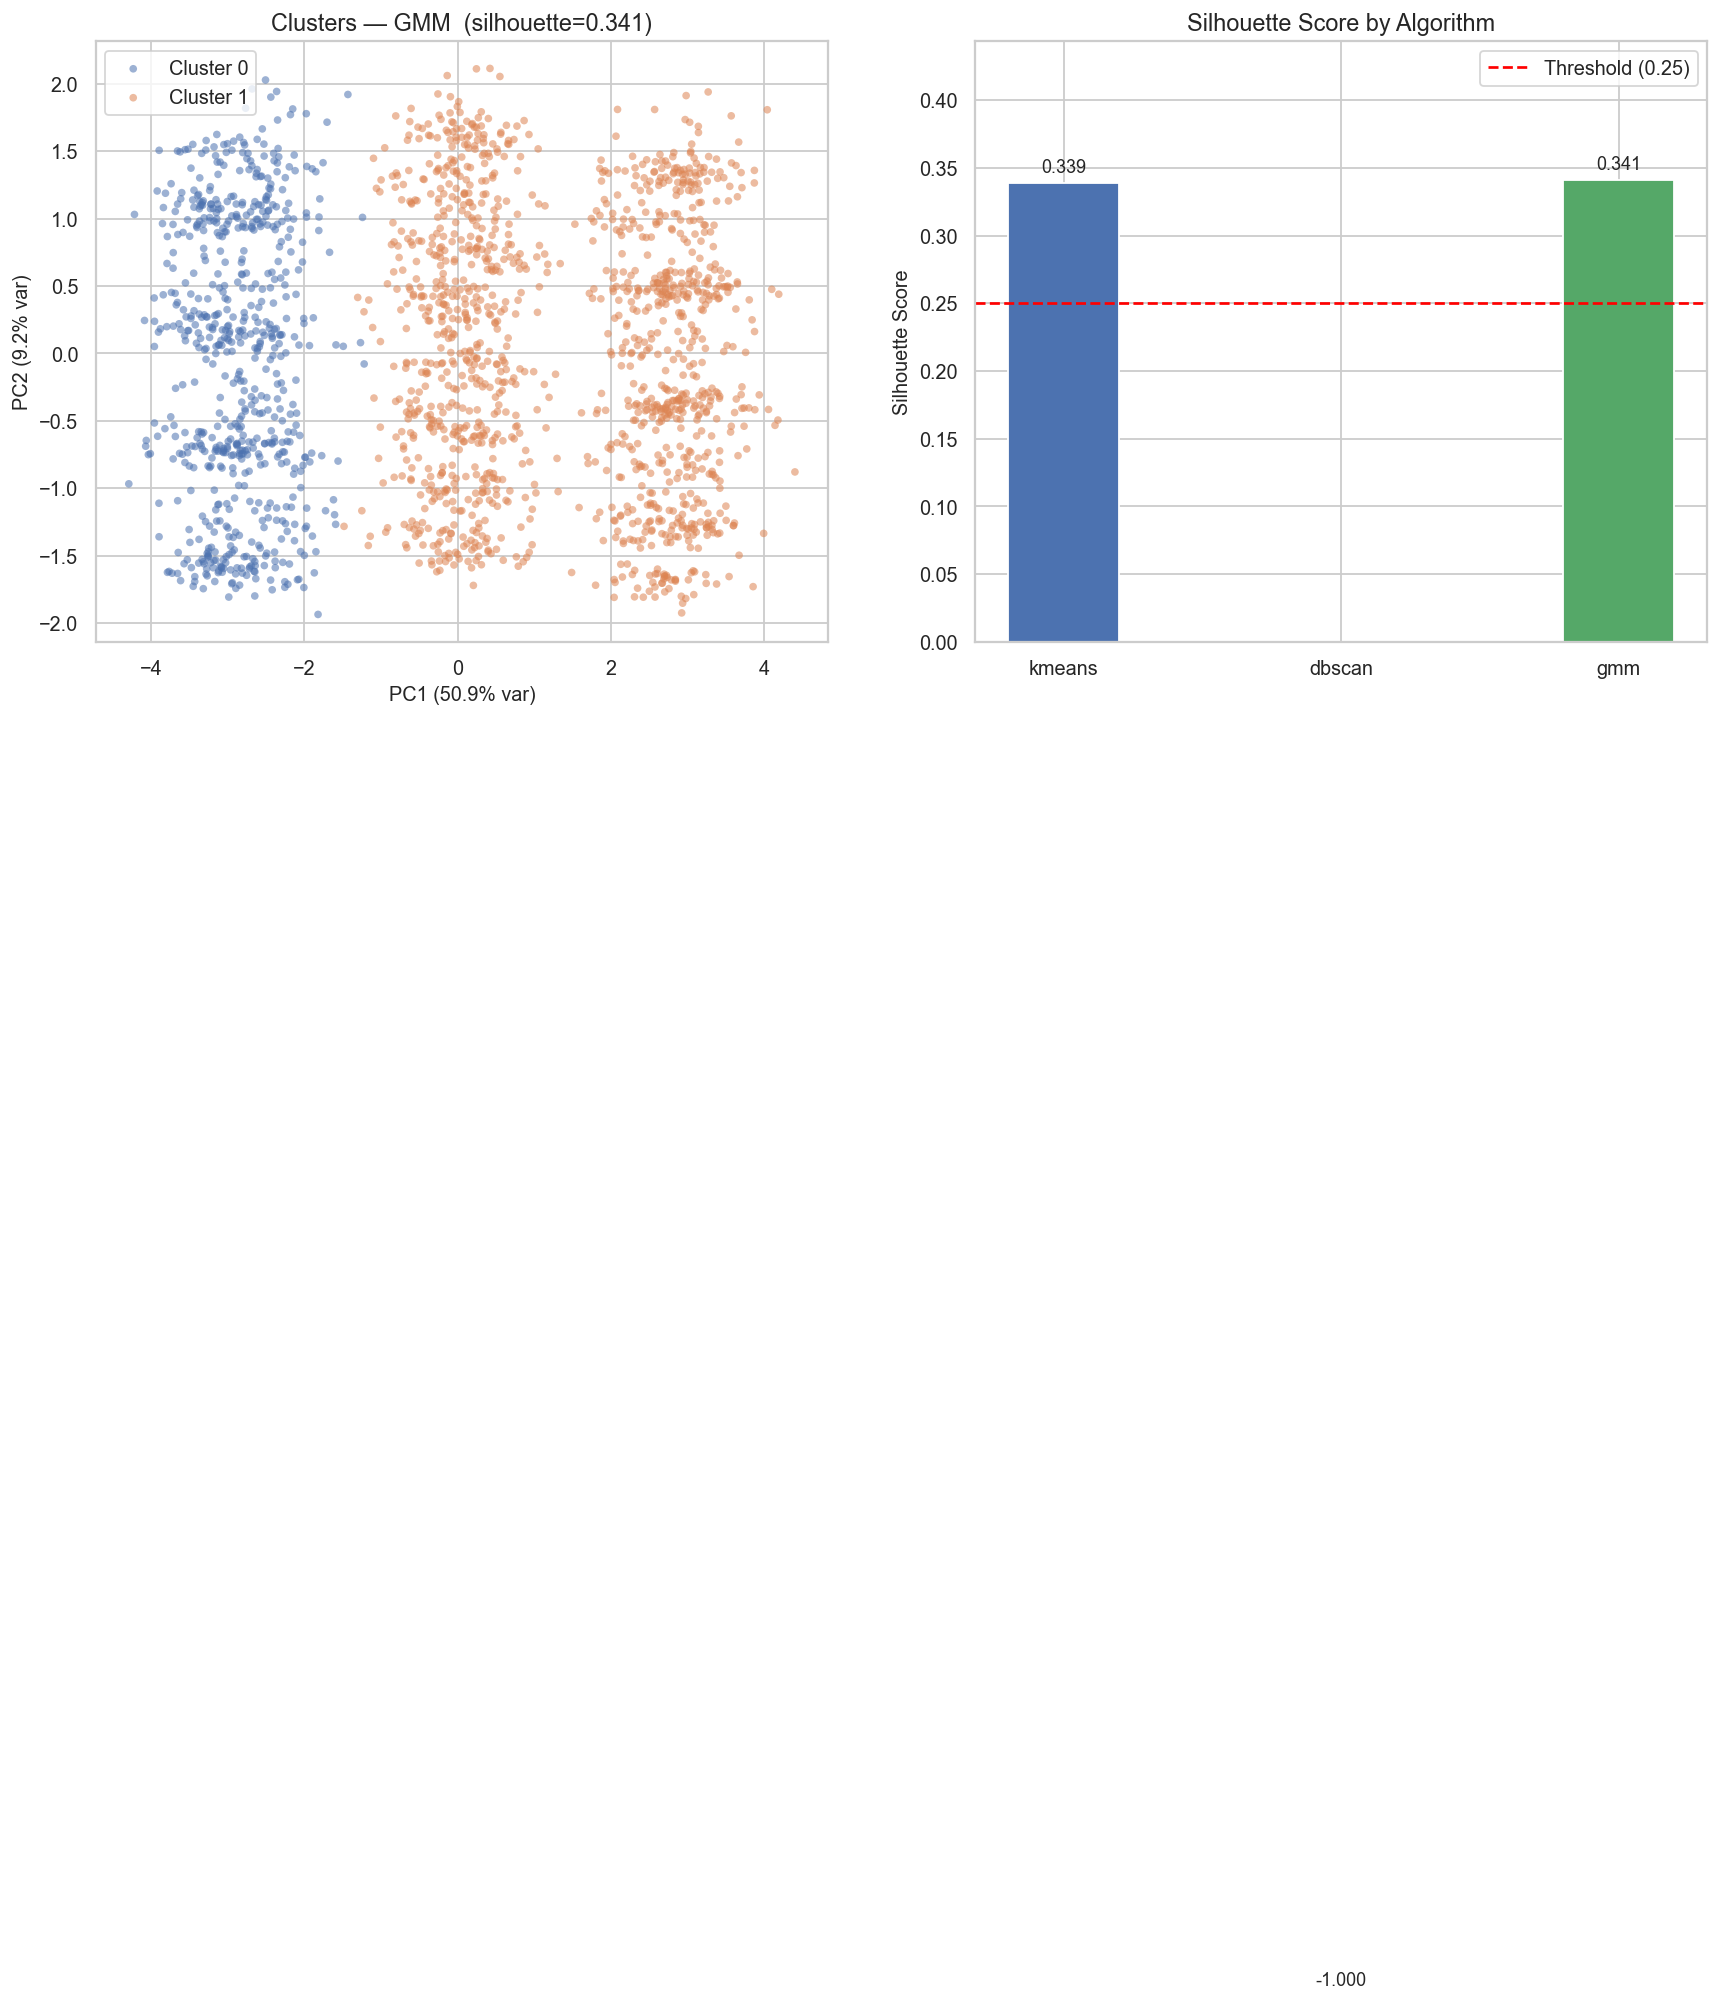

✅ Saved: cluster_visualisation.png


In [9]:
# ── PCA 2D Cluster Visualisation ─────────────────────────────────────────────

pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X)
var_explained = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: cluster scatter ─────────────────────────────────────────────────────
labels_for_plot = best_eval.labels
unique_labels = sorted(set(labels_for_plot))
colors = PALETTE[:len(unique_labels)]

for lbl, col in zip(unique_labels, colors):
    mask = labels_for_plot == lbl
    label_name = f"Cluster {lbl}" if lbl != -1 else "Noise"
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=col, alpha=0.55, s=18, label=label_name, edgecolors="none")

axes[0].set_title(
    f"Clusters — {best_eval.algorithm.upper()}  "
    f"(silhouette={best_eval.silhouette:.3f})"
)
axes[0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% var)")
axes[0].legend(framealpha=0.8)

# ── Right: evaluation score comparison bar chart ──────────────────────────────
algos  = list(best_eval.all_scores.keys())
sil_sc = [best_eval.all_scores[a]["silhouette"] for a in algos]
bar_colors = [PALETTE[2] if a == best_eval.algorithm else PALETTE[0] for a in algos]

bars = axes[1].bar(algos, sil_sc, color=bar_colors, width=0.4, edgecolor="white")
axes[1].axhline(SILHOUETTE_THRESHOLD, color="red", linestyle="--",
                linewidth=1.5, label=f"Threshold ({SILHOUETTE_THRESHOLD})")
axes[1].set_ylim(0, max(sil_sc) * 1.3)
axes[1].set_title("Silhouette Score by Algorithm")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
for bar, val in zip(bars, sil_sc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: cluster_visualisation.png")


## Cell 10 — Explainability Layer
Permutation-based feature importance (SHAP-style), PCA loadings, and inertia movement analysis.

In [10]:
# ── Explainability Layer ─────────────────────────────────────────────────────
# Computes: (1) permutation feature importance, (2) PCA component loadings,
# (3) per-cluster feature means for interpretability.

@dataclass
class ExplainabilityReport:
    top_features: list[str]
    feature_importances: dict[str, float]   # feature → importance score
    pca_loadings: pd.DataFrame              # component × feature
    cluster_profiles: pd.DataFrame          # cluster × feature mean (raw scale)
    pca_variance_ratio: list[float]


def compute_permutation_importance(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: list[str],
    n_repeats: int = 10,
) -> dict[str, float]:
    """
    Permutation importance: how much does silhouette drop when feature is shuffled?
    Higher drop → feature is more important for cluster separation.
    """
    rng = np.random.default_rng(0)
    valid_mask = labels != -1
    Xv, lv = X[valid_mask], labels[valid_mask]

    if len(set(lv)) < 2:
        return {f: 0.0 for f in feature_names}

    baseline = silhouette_score(Xv, lv, sample_size=min(1000, len(Xv)))
    importances: dict[str, float] = {}

    for i, fname in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            Xp = Xv.copy()
            rng.shuffle(Xp[:, i])
            s = silhouette_score(Xp, lv, sample_size=min(1000, len(Xv)))
            drops.append(baseline - s)
        importances[fname] = round(float(np.mean(drops)), 5)

    return dict(sorted(importances.items(), key=lambda x: -x[1]))


def build_explainability_report(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: list[str],
    raw_df: pd.DataFrame,
    n_top: int,
) -> ExplainabilityReport:
    print("  Computing permutation feature importances...")
    importances = compute_permutation_importance(X, labels, feature_names)
    top_features = list(importances.keys())[:n_top]

    print("  Computing PCA loadings...")
    n_components = min(5, len(feature_names))
    pca_full = PCA(n_components=n_components, random_state=42)
    pca_full.fit(X)
    loadings_df = pd.DataFrame(
        np.abs(pca_full.components_),
        columns=feature_names,
        index=[f"PC{i+1}" for i in range(n_components)],
    )

    print("  Computing per-cluster profiles...")
    profiled = raw_df.copy()
    profiled["_cluster"] = labels
    num_cols = [c for c in schema.numeric_cols if c in profiled.columns]
    cluster_profiles = profiled.groupby("_cluster")[num_cols].mean().round(2)

    return ExplainabilityReport(
        top_features        = top_features,
        feature_importances = importances,
        pca_loadings        = loadings_df,
        cluster_profiles    = cluster_profiles,
        pca_variance_ratio  = pca_full.explained_variance_ratio_.tolist(),
    )


print("⏳ Building explainability report (may take ~30s)...")
t0 = time.time()
explain_report = build_explainability_report(
    X, best_eval.labels, fe.feature_names, raw_df, N_TOP_FEATURES
)
print(f"✅ Explainability complete in {time.time()-t0:.1f}s")
print(f"   Top {N_TOP_FEATURES} driving features: {explain_report.top_features}")


⏳ Building explainability report (may take ~30s)...
  Computing permutation feature importances...
  Computing PCA loadings...
  Computing per-cluster profiles...
✅ Explainability complete in 1.9s
   Top 8 driving features: ['days_since_last_purchase', 'age', 'avg_order_value', 'nps_score', 'annual_spend', 'purchase_frequency', 'lifetime_months', 'product_category']


## Cell 11 — Explainability Plots

KeyError: "['product_category'] not in index"

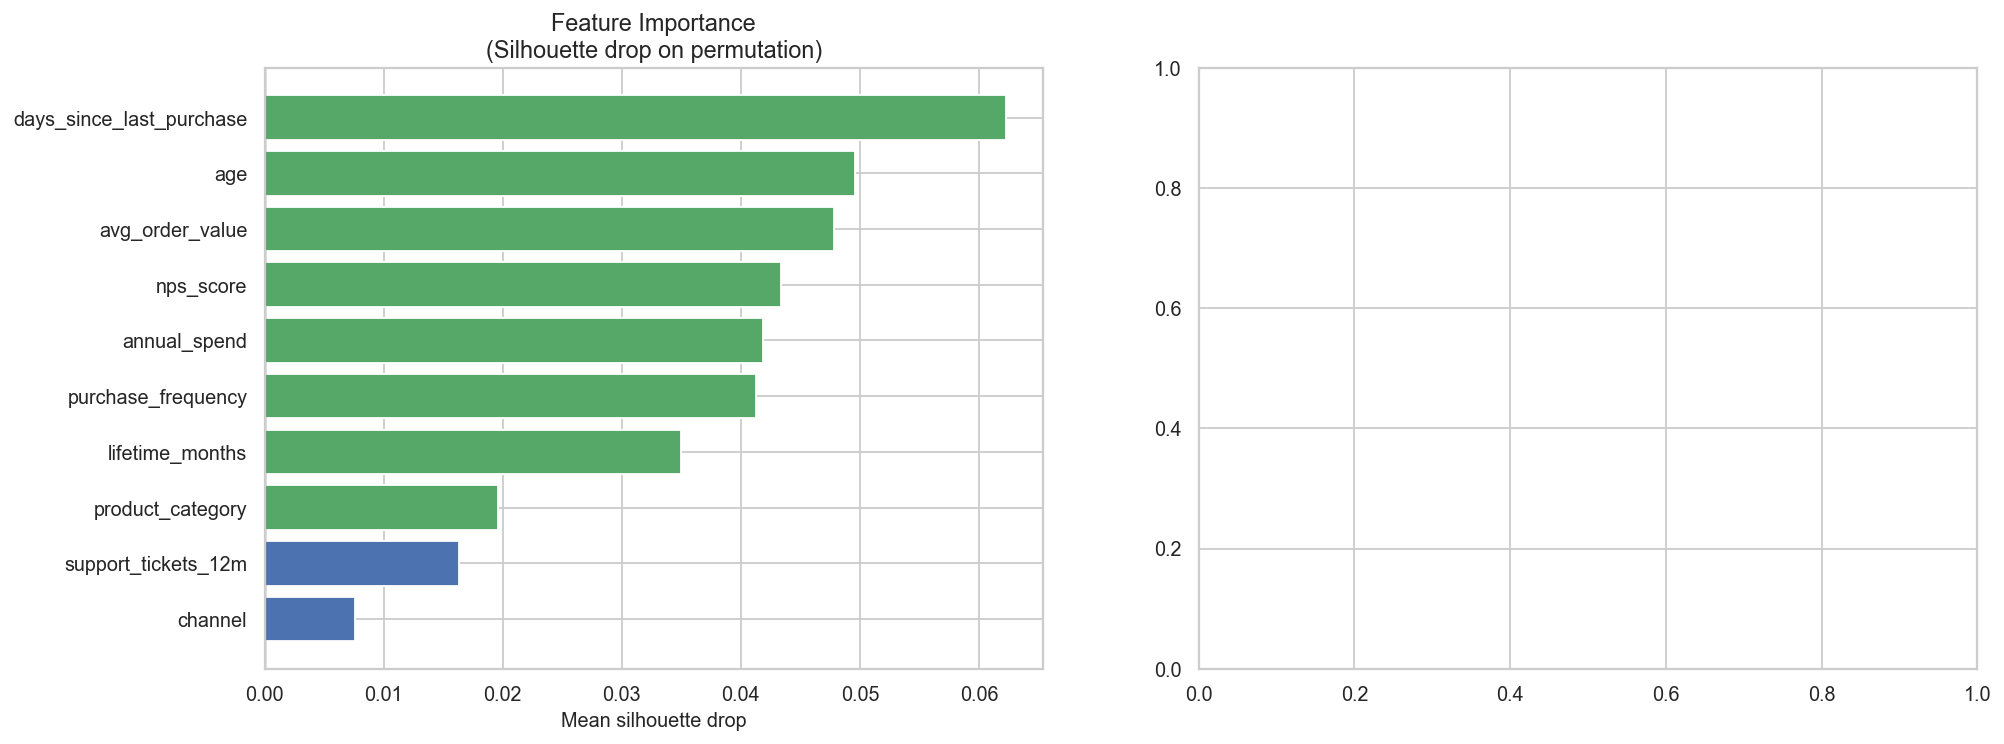

In [11]:
# ── Explainability Plots ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Left: feature importance bar ─────────────────────────────────────────────
top_n = 10
names  = list(explain_report.feature_importances.keys())[:top_n]
scores = list(explain_report.feature_importances.values())[:top_n]
bar_c  = [PALETTE[2] if n in explain_report.top_features else PALETTE[0] for n in names]

axes[0].barh(names[::-1], scores[::-1], color=bar_c[::-1], edgecolor="white")
axes[0].set_title("Feature Importance\n(Silhouette drop on permutation)")
axes[0].set_xlabel("Mean silhouette drop")
axes[0].axvline(0, color="gray", linewidth=0.8)

# ── Right: cluster profile heatmap ───────────────────────────────────────────
profile_z = (explain_report.cluster_profiles - explain_report.cluster_profiles.mean()) \
            / explain_report.cluster_profiles.std().replace(0, 1)
profile_z = profile_z[explain_report.top_features[:8]]  # keep top features

sns.heatmap(
    profile_z.T, ax=axes[1],
    cmap="RdBu_r", center=0, annot=True, fmt=".2f",
    linewidths=0.5, cbar_kws={"label": "Z-score vs. mean"},
)
axes[1].set_title("Cluster Profiles — Top Driving Features\n(Z-scored mean values)")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "explainability.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: explainability.png")


## Cell 12 — Local LLM Client (Ollama)
Thin client wrapping the Ollama `/api/generate` endpoint. Handles streaming, retries, and JSON extraction.

In [12]:
# ── Ollama Local LLM Client ──────────────────────────────────────────────────

class OllamaClient:
    """
    Thin, production-grade client for Ollama's local LLM API.
    Supports streaming, retries, timeout, and structured JSON extraction.
    """

    def __init__(self, host: str, model: str, timeout: int = 120):
        self.host    = host.rstrip("/")
        self.model   = model
        self.timeout = timeout
        self._endpoint = f"{self.host}/api/generate"

    def health_check(self) -> bool:
        try:
            r = requests.get(f"{self.host}/api/tags", timeout=5)
            models = [m["name"] for m in r.json().get("models", [])]
            available = any(self.model in m for m in models)
            if not available:
                print(f"⚠️  Model '{self.model}' not found. Available: {models}")
            return True
        except Exception as e:
            print(f"❌ Ollama not reachable at {self.host}: {e}")
            return False

    def generate(
        self,
        prompt: str,
        system: str | None = None,
        temperature: float = 0.3,
        max_retries: int = 2,
    ) -> str:
        """
        Generate a response. Returns the full text.
        Retries on transient errors.
        """
        payload: dict = {
            "model":  self.model,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": 1024,
            },
        }
        if system:
            payload["system"] = system

        last_error = None
        for attempt in range(1, max_retries + 2):
            try:
                r = requests.post(
                    self._endpoint,
                    json=payload,
                    timeout=self.timeout,
                )
                r.raise_for_status()
                return r.json().get("response", "").strip()
            except requests.Timeout:
                last_error = f"Timeout after {self.timeout}s"
            except requests.RequestException as e:
                last_error = str(e)
            if attempt <= max_retries:
                wait = 2 ** attempt
                log.warning("Ollama attempt %d failed (%s). Retrying in %ds...", attempt, last_error, wait)
                time.sleep(wait)

        raise RuntimeError(f"Ollama failed after {max_retries+1} attempts: {last_error}")

    def extract_json(self, text: str) -> dict | list:
        """Extract the first JSON object/array from LLM output."""
        match = re.search(r"(\{.*\}|\[.*\])", text, re.DOTALL)
        if not match:
            raise ValueError(f"No JSON found in LLM response:\n{text[:400]}")
        return json.loads(match.group(1))


# ── Initialise and health-check ───────────────────────────────────────────────
ollama = OllamaClient(OLLAMA_HOST, OLLAMA_MODEL, OLLAMA_TIMEOUT)
is_up  = ollama.health_check()

if is_up:
    print(f"✅ Ollama is reachable at {OLLAMA_HOST}")
    print(f"   Model: {OLLAMA_MODEL}")
else:
    print(f"\n⚠️  Ollama is not running. Start it with:  ollama serve")
    print(f"   Then pull the model with:             ollama pull {OLLAMA_MODEL}")
    print(f"\n   Persona identification will use FALLBACK mode (rule-based).")


❌ Ollama not reachable at http://localhost:11434: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/tags (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x00000258F29BCAD0>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))

⚠️  Ollama is not running. Start it with:  ollama serve
   Then pull the model with:             ollama pull llama3

   Persona identification will use FALLBACK mode (rule-based).


## Cell 13 — 🤖 Persona Identification Layer (Local LLM)
For each cluster, builds a rich statistical profile and asks llama3 to generate a named persona with description, traits, and business recommendations.

In [ ]:
# ── Persona Identification Layer ─────────────────────────────────────────────

@dataclass
class PersonaResult:
    cluster_id: int | str
    persona_name: str         # e.g. "Cluster A"
    archetype: str            # e.g. "The Loyal Champion"
    description: str
    key_traits: list[str]
    business_recommendations: list[str]
    cluster_size: int
    cluster_pct: float
    top_features: dict[str, float]   # feature → mean value


PERSONA_SYSTEM_PROMPT = """You are a senior customer analytics expert and strategic advisor.
You analyse customer cluster profiles and generate precise, actionable personas.
Always respond with ONLY valid JSON — no preamble, no explanation, no markdown fences.
The JSON must contain exactly these keys:
  archetype: string (2-5 word evocative label, e.g. 'The Loyal Champion')
  description: string (2-3 sentences describing who this customer is)
  key_traits: list of 4 strings (concise behavioural characteristics)
  business_recommendations: list of 3 strings (specific, actionable strategies)
"""

def build_cluster_profile_text(
    cluster_id: int,
    profile_row: pd.Series,
    cluster_pct: float,
    top_features: dict[str, float],
    top_feature_names: list[str],
) -> str:
    """Build a rich textual summary of a cluster's statistical profile."""
    lines = [
        f"CLUSTER {cluster_id} PROFILE",
        f"  Size: {int(cluster_pct*100)}% of total customers",
        "",
        "  Key metrics (mean values):",
    ]
    for feat in top_feature_names[:8]:
        if feat in profile_row.index:
            lines.append(f"    - {feat}: {profile_row[feat]:.2f}")
    lines += ["", "  Feature importances (contribution to separation):"]
    for feat, imp in list(top_features.items())[:5]:
        lines.append(f"    - {feat}: {imp:.4f}")
    return "\n".join(lines)


def identify_personas_with_llm(
    client: OllamaClient,
    best_eval: EvaluationResult,
    explain_report: ExplainabilityReport,
    raw_df: pd.DataFrame,
    business_objective: str,
    fallback: bool = False,
) -> list[PersonaResult]:
    """
    For each cluster: build profile → call local LLM → parse persona JSON.
    Falls back to rule-based persona labels if Ollama is unavailable.
    """
    personas: list[PersonaResult] = []
    labels = best_eval.labels
    total  = (labels != -1).sum()

    cluster_ids = sorted(c for c in set(labels) if c != -1)

    for cid in cluster_ids:
        mask     = labels == cid
        size     = mask.sum()
        pct      = size / total
        name_map = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E"}
        letter   = name_map.get(cid, str(cid))

        # Numeric profile
        num_cols = [c for c in schema.numeric_cols if c in raw_df.columns]
        profile_row = raw_df[mask][num_cols].mean()
        top_features_dict = {
            k: v for k, v in explain_report.feature_importances.items()
            if v > 0
        }

        profile_text = build_cluster_profile_text(
            cluster_id    = letter,
            profile_row   = profile_row,
            cluster_pct   = pct,
            top_features  = top_features_dict,
            top_feature_names = explain_report.top_features,
        )

        if fallback:
            # Rule-based fallback when Ollama is unavailable
            archetype   = f"Cluster {letter} Persona"
            description = f"Cluster {letter} contains {size:,} customers ({pct*100:.1f}% of total). Statistical profiling complete; LLM descriptions require Ollama."
            key_traits  = [f"Cluster size: {size:,}", f"Share: {pct*100:.1f}%",
                           "LLM offline — run ollama serve", "Retrigger Cell 13"]
            recs        = ["Start Ollama: ollama serve", f"Pull model: ollama pull {OLLAMA_MODEL}", "Re-run this cell"]
        else:
            prompt = (
                f"Business objective: {business_objective}\n\n"
                f"{profile_text}\n\n"
                f"Generate a precise customer persona for Cluster {letter}. "
                f"The persona must be grounded in the metrics above and serve the stated business objective. "
                f"Respond ONLY with valid JSON."
            )
            print(f"  🤖 Calling {OLLAMA_MODEL} for Cluster {letter} ({size:,} customers)...")
            t0 = time.time()
            raw_response = client.generate(prompt, system=PERSONA_SYSTEM_PROMPT, temperature=0.3)
            elapsed_llm = time.time() - t0
            print(f"     Response in {elapsed_llm:.1f}s")

            try:
                parsed = client.extract_json(raw_response)
                archetype   = parsed.get("archetype", f"Cluster {letter} Persona")
                description = parsed.get("description", "")
                key_traits  = parsed.get("key_traits", [])
                recs        = parsed.get("business_recommendations", [])
            except (ValueError, json.JSONDecodeError) as e:
                log.warning("  JSON parse failed for cluster %s: %s", letter, e)
                archetype   = f"Cluster {letter}"
                description = raw_response[:300]
                key_traits  = []
                recs        = []

        personas.append(PersonaResult(
            cluster_id               = cid,
            persona_name             = f"Cluster {letter}",
            archetype                = archetype,
            description              = description,
            key_traits               = key_traits,
            business_recommendations = recs,
            cluster_size             = int(size),
            cluster_pct              = round(float(pct), 4),
            top_features             = {k: round(float(profile_row.get(k, 0)), 2)
                                        for k in explain_report.top_features[:5]
                                        if k in profile_row.index},
        ))

    return personas


# ── Execute Persona Identification ────────────────────────────────────────────
use_fallback = not is_up

print("\n" + "═"*60)
print("  PERSONA IDENTIFICATION LAYER")
print("  Using local LLM:" if not use_fallback else "  ⚠️  Using rule-based FALLBACK (Ollama offline)")
print("═"*60)

personas = identify_personas_with_llm(
    client           = ollama,
    best_eval        = best_eval,
    explain_report   = explain_report,
    raw_df           = raw_df,
    business_objective = BUSINESS_OBJECTIVE,
    fallback         = use_fallback,
)

print(f"\n✅ {len(personas)} personas identified.")


## Cell 14 — Ground in Business Objective
LLM synthesises a strategic summary mapping all personas to the business objective, then assigns each to Cluster A / B / C buckets.

In [ ]:
# ── Business Objective Grounding ─────────────────────────────────────────────

GROUNDING_SYSTEM = """You are a Chief Strategy Officer synthesising customer segmentation results
into an executive-level strategic report.
Respond with ONLY valid JSON containing:
  executive_summary: string (3-4 sentences — overall findings and strategic implication)
  cluster_priority: list of objects, each with:
    cluster: string
    archetype: string
    priority: string  ("High" | "Medium" | "Low")
    strategic_action: string (one concrete next action)
  quick_wins: list of 3 strings (immediate actions any team can take this week)
"""

def ground_in_business_objective(
    client: OllamaClient,
    personas: list[PersonaResult],
    objective: str,
    fallback: bool = False,
) -> dict:
    if fallback:
        return {
            "executive_summary": "Ollama offline. Start Ollama and re-run to get LLM-generated strategic grounding.",
            "cluster_priority":  [{"cluster": p.persona_name, "archetype": p.archetype,
                                   "priority": "TBD", "strategic_action": "Run Ollama to generate"} for p in personas],
            "quick_wins": ["Start Ollama: ollama serve", f"Pull model: ollama pull {OLLAMA_MODEL}", "Re-run notebook"],
        }

    persona_summaries = []
    for p in personas:
        persona_summaries.append(
            f"  {p.persona_name} — {p.archetype}\n"
            f"    Size: {p.cluster_size:,} ({p.cluster_pct*100:.1f}%)\n"
            f"    Description: {p.description[:200]}\n"
            f"    Top traits: {'; '.join(p.key_traits[:3])}"
        )

    prompt = (
        f"Business Objective:\n{objective}\n\n"
        f"Identified Customer Personas:\n" + "\n\n".join(persona_summaries) + "\n\n"
        f"Ground these personas in the stated business objective. "
        f"Identify priorities and strategic actions. Respond ONLY with valid JSON."
    )

    print("  🤖 Grounding personas in business objective...")
    t0 = time.time()
    raw = client.generate(prompt, system=GROUNDING_SYSTEM, temperature=0.2)
    print(f"     LLM response in {time.time()-t0:.1f}s")

    try:
        return client.extract_json(raw)
    except Exception as e:
        log.warning("Grounding JSON parse failed: %s", e)
        return {"executive_summary": raw[:500], "cluster_priority": [], "quick_wins": []}


grounding = ground_in_business_objective(ollama, personas, BUSINESS_OBJECTIVE, fallback=use_fallback)

print("\n" + "═"*60)
print("  BUSINESS OBJECTIVE GROUNDING COMPLETE")
print("═"*60)
print("\n📋 Executive Summary:")
print(f"   {grounding.get('executive_summary', 'N/A')}")


## Cell 15 — 📊 Final Persona Report
Prints the full structured output: Cluster A, B, C with archetypes, traits, recommendations, and strategic grounding.

In [ ]:
# ── Final Persona Report ─────────────────────────────────────────────────────

CLUSTER_LETTERS = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E"}

def print_persona_report(personas: list[PersonaResult], grounding: dict, objective: str):
    divider  = "═" * 68
    subdiv   = "─" * 68

    print(f"\n{divider}")
    print(f"  PERSONA IDENTIFICATION REPORT")
    print(f"  Business Objective: {objective[:70]}...")
    print(f"{divider}")

    for p in personas:
        letter = CLUSTER_LETTERS.get(p.cluster_id, str(p.cluster_id))
        print(f"\n{'▌'} CLUSTER {letter}  ╔══ {p.archetype} ══╗")
        print(f"  Size        : {p.cluster_size:,} customers  ({p.cluster_pct*100:.1f}% of total)")
        print(f"  Description :")
        # Word-wrap the description
        words, line = p.description.split(), ""
        for word in words:
            if len(line) + len(word) + 1 > 65:
                print(f"    {line}")
                line = word
            else:
                line = f"{line} {word}".strip()
        if line:
            print(f"    {line}")

        if p.key_traits:
            print(f"  Key Traits  :")
            for t in p.key_traits:
                print(f"    • {t}")

        if p.top_features:
            print(f"  Top Metrics (mean):")
            for feat, val in p.top_features.items():
                print(f"    {feat:<30}: {val:>10.2f}")

        if p.business_recommendations:
            print(f"  Recommendations:")
            for r in p.business_recommendations:
                print(f"    → {r}")
        print(f"  {subdiv}")

    # Strategic priorities
    priorities = grounding.get("cluster_priority", [])
    if priorities:
        print(f"\n{'▌'} STRATEGIC PRIORITIES")
        for cp in priorities:
            print(f"  [{cp.get('priority','?'):6}] {cp.get('cluster','')} — {cp.get('strategic_action','')}")

    # Quick wins
    qw = grounding.get("quick_wins", [])
    if qw:
        print(f"\n{'▌'} QUICK WINS (This Week)")
        for i, w in enumerate(qw, 1):
            print(f"  {i}. {w}")

    print(f"\n{divider}\n")


print_persona_report(personas, grounding, BUSINESS_OBJECTIVE)


## Cell 16 — Persona Visualisation
Radar chart per cluster + cluster size distribution.

In [ ]:
# ── Persona Visualisation ────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 7))

# ── Left: cluster size pie ────────────────────────────────────────────────────
ax_pie = fig.add_subplot(1, 3, 1)
sizes  = [p.cluster_size for p in personas]
labels_pie = [f"{p.persona_name}\n{p.archetype[:20]}" for p in personas]
wedge_colors = PALETTE[:len(personas)]

wedges, texts, autotexts = ax_pie.pie(
    sizes, labels=labels_pie, colors=wedge_colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for at in autotexts:
    at.set_fontsize(10)
ax_pie.set_title("Cluster Size Distribution", fontsize=13, pad=15)

# ── Right: radar charts ───────────────────────────────────────────────────────
top_radar_feats = explain_report.top_features[:6]
num_cols_radar  = [f for f in top_radar_feats if f in raw_df.columns
                   and pd.api.types.is_numeric_dtype(raw_df[f])][:6]
n_feats = len(num_cols_radar)

if n_feats >= 3:
    angles = np.linspace(0, 2 * np.pi, n_feats, endpoint=False).tolist()
    angles += angles[:1]

    for idx, p in enumerate(personas[:3]):
        ax = fig.add_subplot(1, 3, idx + 2, polar=True) if idx < 2 else None
        if idx == 0:
            ax = fig.add_subplot(1, 3, 2, polar=True)
        elif idx == 1:
            ax = fig.add_subplot(1, 3, 3, polar=True)
        else:
            break

        mask   = best_eval.labels == p.cluster_id
        means  = raw_df[mask][num_cols_radar].mean()
        global_min = raw_df[num_cols_radar].min()
        global_max = raw_df[num_cols_radar].max()
        normed = ((means - global_min) / (global_max - global_min + 1e-9)).values.tolist()
        normed += normed[:1]

        ax.plot(angles, normed, color=PALETTE[idx], linewidth=2)
        ax.fill(angles, normed, color=PALETTE[idx], alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(num_cols_radar, size=8)
        ax.set_ylim(0, 1)
        ax.set_title(f"{p.persona_name}\n{p.archetype[:18]}", size=10, pad=14,
                     color=PALETTE[idx], fontweight="bold")

plt.suptitle("Customer Persona Profiles", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "persona_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: persona_profiles.png")


## Cell 17 — Export Results
Saves labeled dataset (CSV), persona report (JSON), and pipeline metadata.

In [ ]:
# ── Export Results ───────────────────────────────────────────────────────────

# 1. Labeled dataset
cluster_letter_map = {p.cluster_id: p.persona_name for p in personas}
labeled_df["persona"] = labeled_df["cluster_id"].map(cluster_letter_map).fillna("Noise")
labeled_df["archetype"] = labeled_df["cluster_id"].map(
    {p.cluster_id: p.archetype for p in personas}
).fillna("N/A")

output_csv = OUTPUT_DIR / "labeled_customers.csv"
labeled_df.to_csv(output_csv, index=False)
print(f"✅ Labeled dataset  → {output_csv}")

# 2. Persona report JSON
report = {
    "pipeline_metadata": {
        "algorithm":           best_eval.algorithm,
        "n_clusters":          best_eval.n_clusters,
        "silhouette_score":    best_eval.silhouette,
        "davies_bouldin":      best_eval.davies_bouldin,
        "calinski_harabasz":   best_eval.calinski_harabasz,
        "top_features":        explain_report.top_features,
        "ollama_model":        OLLAMA_MODEL,
        "business_objective":  BUSINESS_OBJECTIVE,
    },
    "personas": [
        {
            "cluster_id":               p.cluster_id,
            "persona_name":             p.persona_name,
            "archetype":                p.archetype,
            "description":              p.description,
            "key_traits":               p.key_traits,
            "business_recommendations": p.business_recommendations,
            "cluster_size":             p.cluster_size,
            "cluster_pct":              p.cluster_pct,
            "top_feature_means":        p.top_features,
        }
        for p in personas
    ],
    "strategic_grounding": grounding,
}

output_json = OUTPUT_DIR / "persona_report.json"
with open(output_json, "w") as f:
    json.dump(report, f, indent=2)
print(f"✅ Persona report   → {output_json}")

# 3. Per-cluster CSVs
for p in personas:
    mask = labeled_df["cluster_id"] == p.cluster_id
    out  = OUTPUT_DIR / f"{p.persona_name.replace(' ','_').lower()}_customers.csv"
    labeled_df[mask].to_csv(out, index=False)
    print(f"✅ {p.persona_name} customers → {out}  ({mask.sum():,} rows)")

print(f"\n🎉 Pipeline complete. All outputs in: {OUTPUT_DIR.resolve()}/")


## ✅ Pipeline Architecture Summary

| Step | Module | Description |
|------|--------|-------------|
| 1 | **Data Input** | CSV / Parquet / Excel / Synthetic loader with schema inference |
| 2 | **Feature Engineering** | Imputation → Label encoding → IQR clipping → StandardScaler |
| 3 | **Clustering Config** | Silhouette-guided k selection over configurable k range |
| 4 | **K-Means Runner** | Distance-based clustering with k-means++ initialisation |
| 5 | **DBSCAN Runner** | Density-based clustering; handles irregular cluster shapes |
| 6 | **GMM Runner** | Probabilistic soft assignment via Expectation-Maximization |
| 7 | **Cluster Evaluator** | Silhouette + Davies-Bouldin + Calinski-Harabasz; pass/fail gate |
| 8 | **Modeling Loop** | Retries up to `MAX_ITERATIONS` with reconfiguration on failure |
| 9 | **Explainability** | Permutation feature importance + PCA loadings + cluster profiles |
| 10 | **Persona ID (LLM)** | Ollama/llama3 generates archetype, traits, recommendations per cluster |
| 11 | **Business Grounding** | LLM synthesises executive summary + strategic priorities |
| 12 | **Export** | Labeled CSV, per-cluster CSVs, full JSON report, PNG plots |

### Local LLM Setup
```bash
# 1. Install Ollama
curl -fsSL https://ollama.com/install.sh | sh

# 2. Start the server
ollama serve

# 3. Pull the model
ollama pull llama3

# 4. Run this notebook end-to-end
```

### Extending the Pipeline
- **Swap LLM**: Change `OLLAMA_MODEL` to `mistral`, `llama3:70b`, `phi3`, etc.
- **Real data**: Set `DATA_SOURCE = "csv"` and `DATA_PATH = "your_file.csv"`
- **More algorithms**: Add new runner functions following the `run_kmeans` pattern
- **SHAP values**: Install `shap` and replace `compute_permutation_importance()` with `shap.KernelExplainer`
